# Coursework Set Week 7

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Kevin Mulder
* Username: kmulder
* Student number: S6121454
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Simpson's rule (4 pt)  <font color='red'><b>COURSEWORK</b></font>

In section 'Simpson's rule' in the task documentation we plotted the function $f(x) = 1 + x + \sin(2x)$

* Create a object-oriented code that the input variables are a function you wish to integral in string and the integral intervals, `a` and `b`.
* Add a function in the object that calculates the integration with the Trapezium rule.
* Add a function in the object that calculates the integration with the Simpson’s rule.
* Add a function in the object that calculates the integration with Monte Carlo integration.
* Add a function in the object that calculates the integration with SymPy (``sympy.integrate()``).
* Add a function in the object that calculates the integration with SciPy (``quad()`` function).
* Use ``a=0.5`` and ``b=3.0`` as the test using all methods you create in the object. Print the test.
  
**Answers**:  

In [2]:
import numpy as np
from sympy import *
from scipy import *
import sympy
from scipy.integrate import quad


class Integration:
    def __init__(self, integral, a, b):
        self.a = a
        self.b = b
        self.integral = integral
        self.f = lambda x: eval(integral, {"np": np, "x": x})

    def Trapezium(self):
        I = (self.b - self.a) * (self.f(self.a) + self.f(self.b)) / 2
        return I

    def Simpson(self):
        n = np.linspace(self.a, self.b, 100000)
        h = (self.b - self.a) / len(n)
        I = h / 3 * (4 * self.f(n[1::2]).sum() + 2 * self.f(n[2::2]).sum() + self.f(n[0]))
        return I

    def Monte_Carlo(self):
        n = np.random.uniform(self.a, self.b, 100000)
        I = (self.b - self.a)/len(n) * np.sum(self.f(n))
        return I

    def SymPy_Integration(self):
        x = sympy.symbols('x')
        function = sympy.sympify(self.integral.replace('np.', ''))
        I = sympy.integrate(function, (x, self.a, self.b))
        return I

    def SciPy_Integration(self):
        I, err = quad(self.f, self.a, self.b)
        return I


s = Integration('1 + x + np.sin(2*x)', 0.5, 3.0)
print(f"Trapezium integration yields: {s.Trapezium()}")  # Difference in values with the others since it uses only 1 trapezoid
print(f"Simpson's integration yields: {s.Simpson()}")
print(f"Monte Carlo integration yields: {s.Monte_Carlo()}")
print(f"SciPy integration yields: {s.SciPy_Integration()}")
print(f"Sympy integration yields: {s.SymPy_Integration()}")

Trapezium integration yields: 7.577569358261213
Simpson's integration yields: 6.665061368994693
Monte Carlo integration yields: 6.666029170297837
SciPy integration yields: 6.6650660096088865
Sympy integration yields: 6.66506600960889


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Fitting a Gaussian model for velocity profile data (16 pt) <font color='red'><b>COURSEWORK</b></font>

For this assignment we use the HI radio FITS cube
[ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)

It contains 101 channel maps with radio interferometer HI data.

1. (3 pt) A global HI profile is a set of measurements at fixed R.A. and Dec. as function of the spectral 
   axis (frequency or velocity). It shows at which frequency (or velocity) there is a peak in HI.
   Plot this profile for R.A. (x) index 58 and Dec. (y) index 55. 
   Label the X axis with the header value ``CUNIT3`` and the Y axis with the intensity 
   units in ``BUNIT``. For this data, the pixels represent brightness.
   
   In the global profile, the first pixel corresponds to 233 km/s and the last pixel corresponds to 377 km/s.
   Convert your X axis from pixel index numbers to km/s (use NumPy's ``linspace()`` to define the X values).
   
**Answer**:

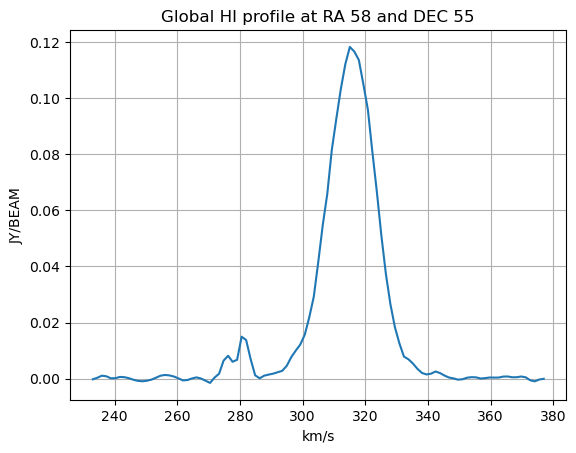

In [4]:
from astropy.io import fits
import numpy as np
from matplotlib.pyplot import figure, show

# Accessing data in fits file
hdul = fits.open('ngc6946.fits')
data = hdul[0].data
header = hdul[0].header

# Cutting out piece of data
profile = data[:, 55, 58]

# Obtaining headers
cunit3 = header.get('CUNIT3')
bunit = header.get('BUNIT')

# Calculating velocity
velocity = np.linspace(233, 377, len(profile))

# Plotting figure
fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(velocity, profile)
frame.set_xlabel(cunit3)
frame.set_ylabel(bunit)
frame.set_title('Global HI profile at RA 58 and DEC 55')
frame.grid()
show()

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

2. (1 pt) Assume the profile can be modeled by a Gaussian. Make a function with signature:

          def f(x, amp, mu, sigma, zero):

   which returns the value of a Gaussian function with amplitude ``amp`` centered at
   position ``mu`` with width ``sigma`` and offset with respect to the x axis of ``zero``
   
**Answer**:   

In [6]:
import numpy as np

def f(x, amp, mu, sigma, zero):
    """Fits a Gaussian model to find properties of the profile"""
    Gaussian = amp * np.exp((-1*(x - mu)**2) / (2*(sigma)**2)) + zero
    return Gaussian

In [7]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Remember how to distinguish linear- from non-linear models. Always look at the derivatives to the parameters.

3. (1 pt) Give a simple proof that this function ``f`` represents a non-linear model

**Answer**:

#### The function is non-linear, since most of the parameters are in the exponent> This means that we will have an exponential growth of the function.

In [8]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Initial estimates are essential for a good fit. If they are not close enough to the real values, you can find a fit but without a guarantee that it is the best fit.

4. (3 pt) For a least squares fit with function `scipy.optimize.curve_fit()` we need reasonable initial estimates. Find reasonable estimates and motivate why you think they are reasonable and then use them as argument ``p0`` in ``curve_fit()`` to find the best fit model parameters and their (scaled) standard errors    

**Answer**:

In [9]:
from scipy.optimize import curve_fit

# Initial paramters
amp0 = np.max(profile)  # Peak of the profile
mu0 = 315  # Peak seems to be at 315, looking at the plot
sigma0 = 10 
zero0 = 0 

p0 = [amp0, mu0, sigma0, zero0]

beta, pcov = curve_fit(f, velocity, profile, p0=p0)
perr = np.sqrt(np.diag(pcov))  # standard errors

print("Best-fit parameters:", beta)
print("Errors:", perr)

Best-fit parameters: [1.16938594e-01 3.15716848e+02 7.26106590e+00 1.34359189e-03]
Errors: [0.00109785 0.07718007 0.08169685 0.00030506]


In [10]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

5. (1 pt) Plot the model curve with its best fit parameter together with the data points    

**Answer**:

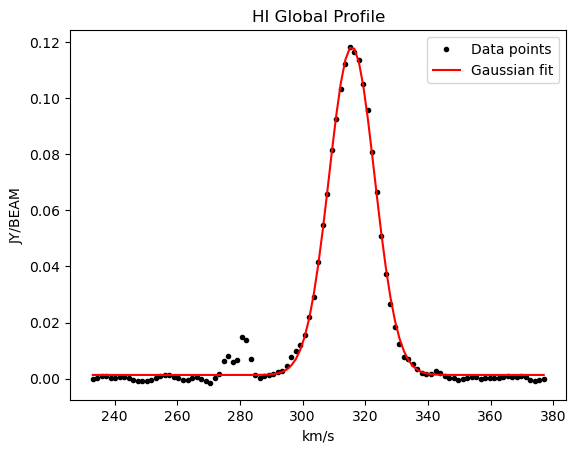

In [11]:
from matplotlib.pyplot import *
from astropy.io import fits
import numpy as np
from scipy.optimize import curve_fit

# Accessing data in fits file
hdul = fits.open('ngc6946.fits')
data = hdul[0].data
header = hdul[0].header

# Cutting out piece of data
profile = data[:, 55, 58]

# Obtaining headers
cunit3 = header.get('CUNIT3')
bunit = header.get('BUNIT')

# Calculating velocity
velocity = np.linspace(233, 377, len(profile))

def f(x, amp, mu, sigma, zero):
    """Fits a Gaussian model to find properties of the profile"""
    Gaussian = amp * np.exp((-1*(x - mu)**2) / (2*(sigma)**2)) + zero
    return Gaussian

# Initial paramters
amp0 = np.max(profile)
mu0 = 315 
sigma0 = 10 
zero0 = 0 

p0 = [amp0, mu0, sigma0, zero0]

beta, pcov = curve_fit(f, velocity, profile, p0=p0)
perr = np.sqrt(np.diag(pcov))  # standard errors

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(velocity, profile, 'k.', label='Data points')
frame.plot(velocity, f(velocity, *beta), c = 'r', label='Gaussian fit')
frame.set_xlabel(cunit3)
frame.set_ylabel(bunit)
frame.legend()
frame.set_title('HI Global Profile')
show()

In [12]:
# Leave unaltered
totalpoints += 1
currentpoints += 0.0

Fitting multiple signals with a Gaussian.

6. (3 pt) If you fit is alright, you see that a small signal at the left of the main signal in your
   profile has not been fitted. You can add a second Gaussian (without a zero level because you 
   already have one offset) to model that second signal.
   Find the best fit parameter of this composed model and plot original data with the best fit curve 
   
**Answer**:

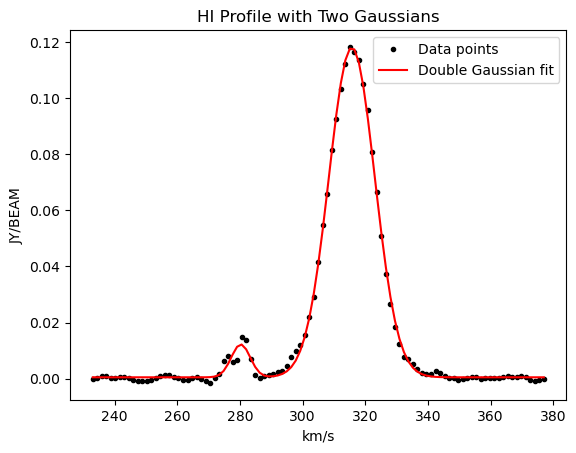

In [13]:
def f2(x, amp1, mu1, sigma1, amp2, mu2, sigma2, zero):
    g1 = amp1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    g2 = amp2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return g1 + g2 + zero

p0_2 = [amp0, mu0, sigma0, amp0/3, mu0 - 20, 5, zero0]

beta2, pcov2 = curve_fit(f2, velocity, profile, p0=p0_2)
perr2 = np.sqrt(np.diag(pcov2))

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(velocity, profile, 'k.', label='Data points')
frame.plot(velocity, f2(velocity, *beta2), c = 'r', label='Double Gaussian fit')
frame.set_xlabel(cunit3)
frame.set_ylabel(bunit)
frame.legend()
frame.set_title('HI Profile with Two Gaussians')
show()

In [14]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

An important characterization of a peak is its width. In astronomy we use the FWHM.

7. (2 pt) What is the FWHM of the gas in the main peak and in the secondary peak. Also give the standard errors 
   in the FWHM. Do not forget to print the units
   
**Answer**:

In [15]:
import numpy as np

# Calculating FWHM
factor = 2 * np.sqrt(2 * np.log(2))
sigma1 = beta2[2]
sigma2 = beta2[5]
fwhm1 = factor * sigma1
fwhm2 = factor * sigma2

# Errors in FWHM
err_sigma1 = perr2[2]
err_sigma2 = perr2[5]
fwhm_err1 = factor * err_sigma1
fwhm_err2 = factor * err_sigma2

print(f"Main peak FWHM = {fwhm1} ± {fwhm_err1} km/s")
print(f"Secondary peak FWHM = {fwhm2} ± {fwhm_err2} km/s")

Main peak FWHM = 17.271768913903525 ± 0.1104576624824544 km/s
Secondary peak FWHM = 7.114996479832584 ± 0.6838162795217626 km/s


In [16]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

8. (2 pt) Plot the FWHM's in the previous plot as horizontal lines at the positions of the fitted peak centers.
   Make the plot complete with labels, title and useful legend



**Answer**:

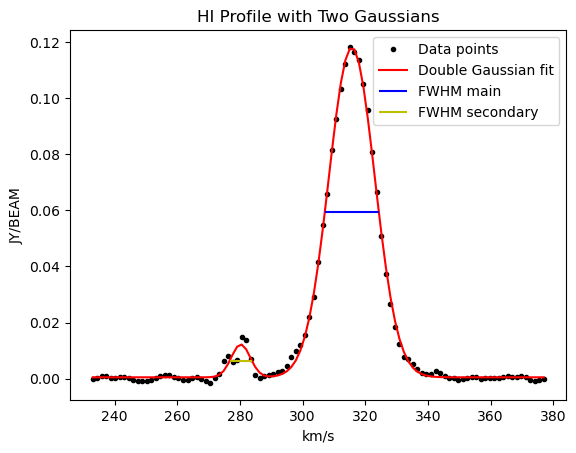

In [17]:
mu1 = beta2[1]
mu2 = beta2[4]

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(velocity, profile, 'k.', label='Data points')
frame.plot(velocity, f2(velocity, *beta2), c = 'r', label='Double Gaussian fit')
frame.set_xlabel(cunit3)
frame.set_ylabel(bunit)
frame.set_title('HI Profile with Two Gaussians')
frame.hlines(beta2[6] + beta2[0]/2, mu1 - fwhm1/2, mu1 + fwhm1/2, color = 'b', label='FWHM main')
frame.hlines(beta2[6] + beta2[3]/2, mu2 - fwhm2/2, mu2 + fwhm2/2, color = 'y', label='FWHM secondary')
frame.legend()
show()

In [18]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

### Smoothing a noisy image (5pt) <font color='red'><b>COURSEWORK</b></font>

Given is a noisy image of a galaxy in FITS file
[faintgalaxy.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/faintgalaxy.fits).
 
To improve the signal to noise ratio in this image, one can smooth the data with a simple algorithm.
    
1. Write a function ``smooth()`` with the following properties:

   * It has an argument ``M`` which is a 2D input image.
   * It returns an output image ``Mc`` with the same shape as the input image.
   * The input and output images do not share memory.
   * Each pixel at location ``(i,j)`` in the output image is the **mean** of 9 input pixels located at:
            
   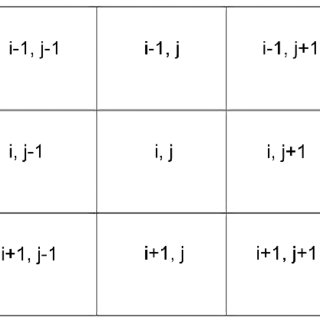    
       
   * Border pixels can be ignored and set to 0.0.
   * Interpolation is not needed.

<br>

2. Create a mosaic with two plots. One shows an image of the original data and the other shows the smoothed version. 
3. Use the function ``smooth2()`` below to smooth ``M`` with a SciPy routine and plot the result.
   
```python
    def smooth2(M):
        Mc = ndimage.gaussian_filter(M, sigma=(1,1), order=0)
        return Mc
```
    
**Strategy**

* The function should leave the original image unaltered, that is, we need to create a copy using one of:

     1. method ``copy()`` 
     1. ``np.zeros()`` 
     1. ``np.zeros_like()`` <br>&nbsp;<br>
   
* For each position (x, y) in the output image, we need to set some value except for the borders:

```python
    for y in range(1, ny-1):
        for x in range(1, nx-1):
```

* Or one uses function numpy.ndindex() and skips the index that represents a border pixel (gives faster code).
* The value of the pixel becomes the average of 9 neighbours in the input. We should then extract a sub-image 
  of 3x3 pixels centered at ``(x,y)``.
* For a 2dim structure ``M``, the pixel at ``(x,y)`` is given by ``M[y,x]``.
* The indices in ``M`` can be a range. To include the left and right, upper and lower neighbours of ``x``,
  we would write ``M[x-1:x+2, y-1:y+2]``.

**Answers**:

/opt/anaconda-hub/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda-hub/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


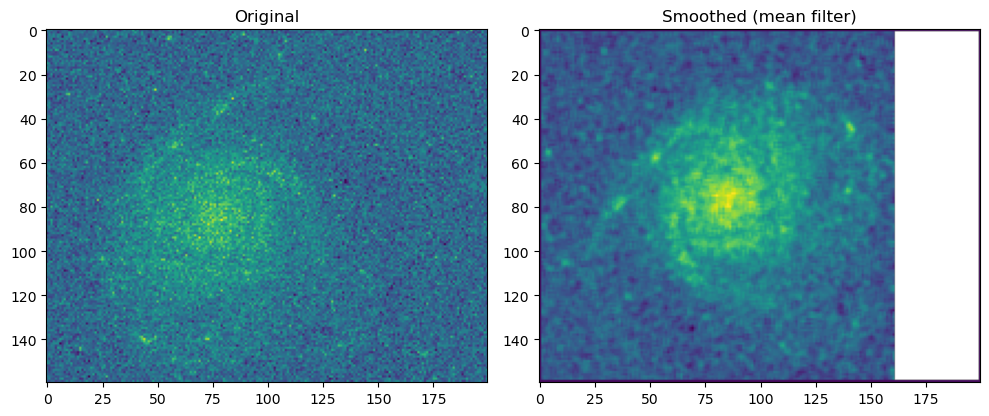

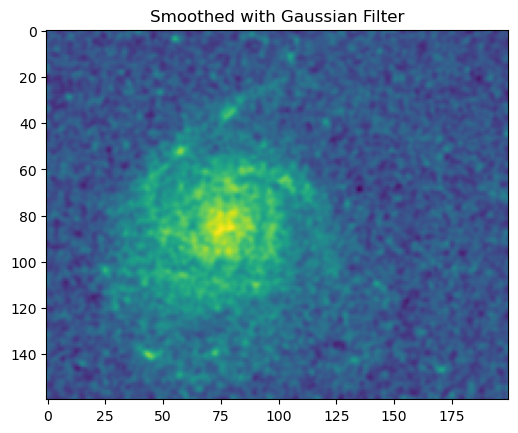

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import ndimage

def smooth(M):
    ny, nx = M.shape
    Mc = np.zeros_like(M)
    for y in range(1, ny-1):
        for x in range(1, nx-1):
            sub_img = M[x-1:x+2, y-1:y+2]
            Mc[y, x] = np.mean(sub_img)
    return Mc

hdul = fits.open('faintgalaxy.fits')
M = hdul[0].data

M_smooth = smooth(M)

fig, frames = plt.subplots(1, 2, figsize=(10, 5))

frames[0].imshow(M)
frames[0].set_title("Original")

frames[1].imshow(M_smooth)
frames[1].set_title("Smoothed (mean filter)")

plt.tight_layout()
plt.show()

# Using smooth2()
def smooth2(M):
    Mc = ndimage.gaussian_filter(M, sigma = (1,1), order = 0)
    return Mc

M_gauss = smooth2(M)
fig, frame = plt.subplots(1, 1)
frame.imshow(M_gauss)
frame.set_title("Smoothed with Gaussian Filter")
plt.show()


In [20]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [21]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 25. Student score: 0.0.  Task Grade = 0.0
